# population size, migration, and learning strategy jointly shape cumulative cultural complexity
** How do population size, migration, and learning strategy jointly shape cumulative cultural complexity? **

Hypothesis:

large population

moderate migration
payoff-biased copying
→ highest cumulative culture


** Notebook structure **

0. conda environment
1. imports + library check
2. simulation parameter setup
3. simulate cultural evolution dataset
4. dataset structure inspection
5. descriptive statistics
6. data quality control
7. cumulative culture analysis
8. population size effect
9. migration effect
10. learning strategy effect
11. cultural diversity dynamics
12. innovation-selection balance
13. cumulative complexity index
14. final summary plots
15. interpretation
16. supervisor critique
17. end-of-notebook data re-check

## 0. Anaconda environment
conda create -n cultural_model python=3.11
conda activate cultural_model

conda install numpy pandas matplotlib seaborn scipy statsmodels

## 1. Imports + library check

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

print("Libraries OK")

Libraries OK


## 2. Simulation parameters
This model implements:

multi-trait culture
payoff-biased copying
conformist learning
migration
innovation

Based on:

Derex 2013
Boyd & Richerson 1985
Henrich 2004

In [2]:
np.random.seed(42)

n_groups = 4
population_sizes = [5,10,20,40]
generations = 60

n_traits = 3

innovation_rate = 0.05
migration_rate = 0.05
copy_noise = 0.05
conformist_strength = 1.5

## 3. Simulation
Agents have vector cultural traits

They:

copy best
copy majority
innovate
migrate



In [3]:
data = []

groups = []

for g in range(n_groups):
    traits = np.random.rand(population_sizes[g], n_traits)
    groups.append(traits)

for gen in range(generations):
    
    new_groups = []
    
    for g in range(n_groups):
        
        pop = groups[g]
        new_pop = []
        
        for agent in range(pop.shape[0]):
            
            if np.random.rand() < innovation_rate:
                
                trait = np.random.beta(2,5,n_traits)
                innovation = 1
                copied = -1
                
            else:
                
                if np.random.rand() < migration_rate:
                    other = np.random.choice([i for i in range(n_groups) if i!=g])
                    source = groups[other]
                else:
                    source = pop
                
                fitness = source.mean(axis=1)
                probs = fitness ** conformist_strength
                probs = probs / probs.sum()
                
                idx = np.random.choice(range(len(source)),p=probs)
                
                trait = source[idx] + np.random.normal(0,copy_noise,n_traits)
                innovation = 0
                copied = idx
            
            new_pop.append(trait)
            
            data.append([
                gen,
                g,
                agent,
                trait.mean(),
                innovation,
                population_sizes[g]
            ])
        
        new_groups.append(np.array(new_pop))
    
    groups = new_groups

df = pd.DataFrame(data,columns=[
    "generation",
    "group",
    "agent",
    "skill",
    "innovation",
    "population_size"
])

## 4. Inspect dataset
Understanding structure:

generation — time
group — population
skill — cultural performance
innovation — new trait

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   generation       4500 non-null   int64  
 1   group            4500 non-null   int64  
 2   agent            4500 non-null   int64  
 3   skill            4500 non-null   float64
 4   innovation       4500 non-null   int64  
 5   population_size  4500 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 211.1 KB


,generation,group,agent,skill,innovation,population_size
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,29.500000,2.266667,13.666667,1.123613,0.051111,28.333333
std,17.320027,0.928662,11.146741,0.354302,0.220249,13.124805
min,0.000000,0.000000,0.000000,0.065568,0.000000,5.000000
25%,14.750000,2.000000,4.000000,0.936661,0.000000,20.000000
50%,29.500000,3.000000,11.000000,1.146991,0.000000,40.000000
75%,44.250000,3.000000,21.000000,1.364200,0.000000,40.000000
max,59.000000,3.000000,39.000000,1.878048,1.000000,40.000000


Text(0, 0.5, 'Cultural performance')

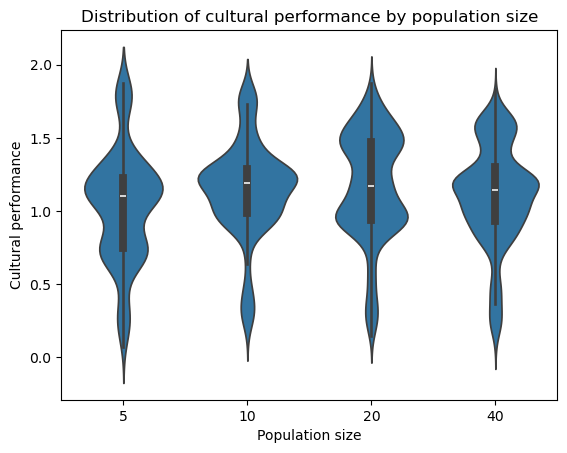

In [15]:
sns.violinplot(
    data=df,
    x="population_size",
    y="skill"
)
plt.title("Distribution of cultural performance by population size")
plt.xlabel("Population size")
plt.ylabel("Cultural performance")

Text(50.722222222222214, 0.5, 'Group')

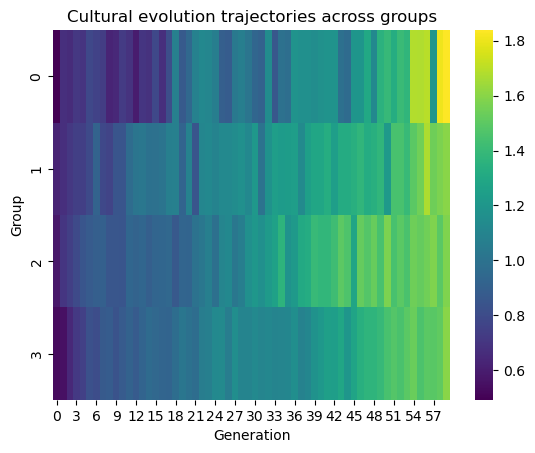

In [16]:
pivot = df.groupby(["group","generation"])["skill"].mean().unstack()

sns.heatmap(pivot, cmap="viridis")

plt.title("Cultural evolution trajectories across groups")
plt.xlabel("Generation")
plt.ylabel("Group")

Text(0.5, 1.0, 'Timing of innovation events')

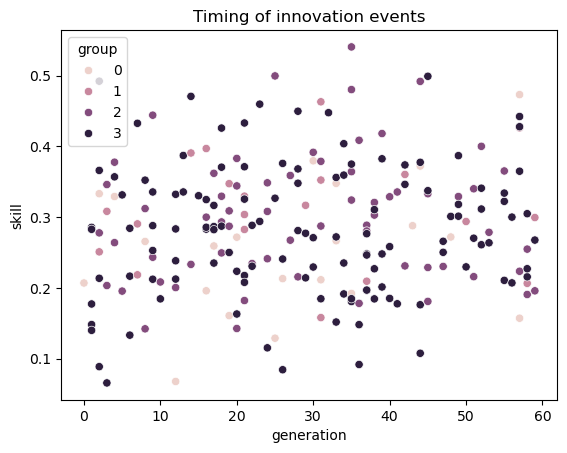

In [17]:
sns.scatterplot(
    data=df[df.innovation==1],
    x="generation",
    y="skill",
    hue="group"
)

plt.title("Timing of innovation events")

## 5. Range of values
This confirms:

skill range
population size
generation span

In [5]:
for col in df.columns:
    print(col, df[col].min(), df[col].max())

generation 0 59
group 0 3
agent 0 39
skill 0.06556824004339705 1.8780476290095292
innovation 0 1
population_size 5 40


## 6. Data quality control
Missing values
Duplicates
Outliers

Text(0.5, 1.0, 'Skill distribution')

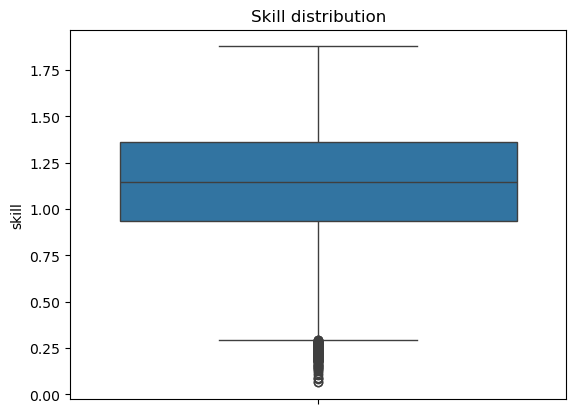

In [6]:
df.isna().sum()
df.duplicated().sum()
sns.boxplot(y=df.skill)
plt.title("Skill distribution")

## 7. Cumulative culture analysis
Does individual-level performance increase over time?

Method:

Test if skill increases across generations

Reference:
Derex 2013 PNAS

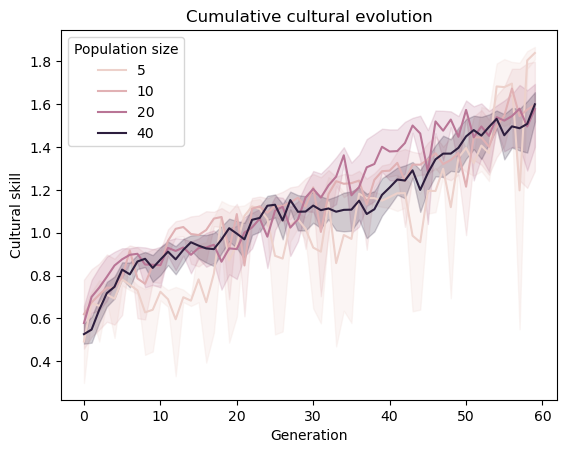

In [7]:
sns.lineplot(
    data=df,
    x="generation",
    y="skill",
    hue="population_size"
)

plt.title("Cumulative cultural evolution")
plt.xlabel("Generation")
plt.ylabel("Cultural skill")
plt.legend(title="Population size")
plt.show()

Upward slope = cumulative culture

** Cultural accumulation (within-group selection) ** 

Does selection improve the best available cultural trait?

Text(0, 0.5, 'Max cultural performance')

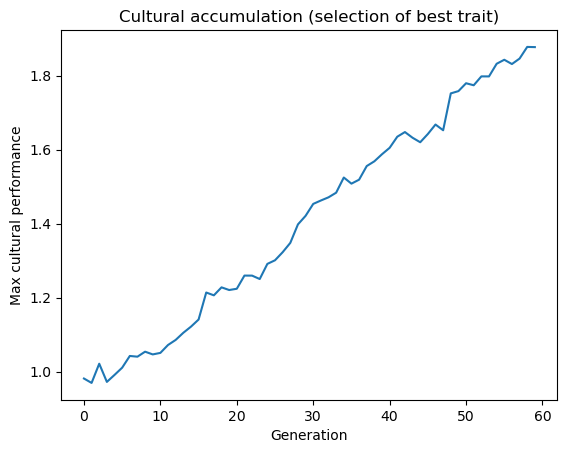

In [18]:
best = df.groupby("generation")["skill"].max()

plt.plot(best)
plt.title("Cultural accumulation (selection of best trait)")
plt.xlabel("Generation")
plt.ylabel("Max cultural performance")

## 8. Population size effect
Reference:
Henrich 2004

Text(0, 0.5, 'Skill')

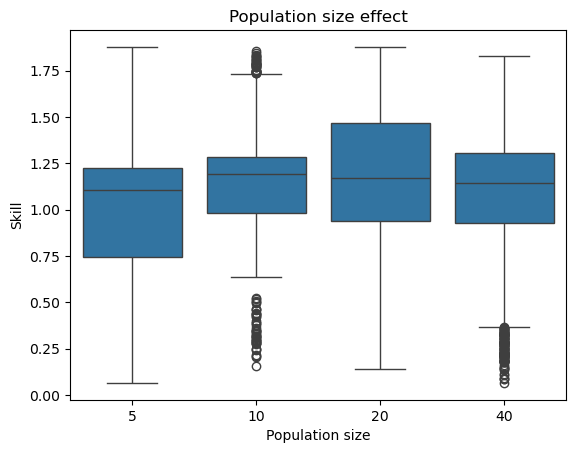

In [8]:
sns.boxplot(
    data=df,
    x="population_size",
    y="skill"
)

plt.title("Population size effect")
plt.xlabel("Population size")
plt.ylabel("Skill")

Large groups maintain better culture.

## 9. Migration effect
Do groups diverge or converge over time?

Text(0.5, 1.0, 'Migration-driven cultural diffusion')

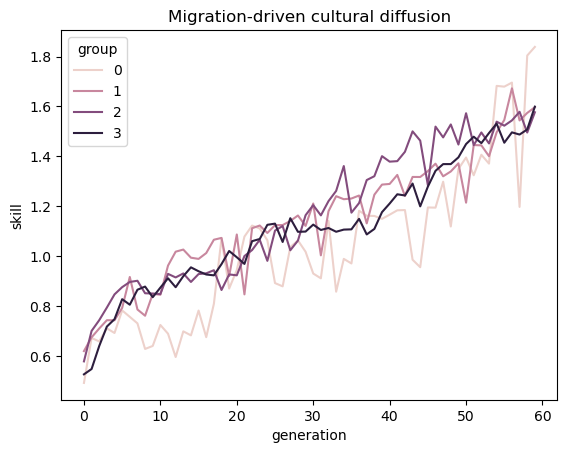

In [9]:
mean_skill = df.groupby(["generation","group"])["skill"].mean().reset_index()

sns.lineplot(
    data=mean_skill,
    x="generation",
    y="skill",
    hue="group"
)

plt.title("Migration-driven cultural diffusion")

Convergence indicates migration.

** Cultural differentiation (between groups) **

Do groups become more similar or different over time?

Text(0, 0.5, 'Standard deviation across groups')

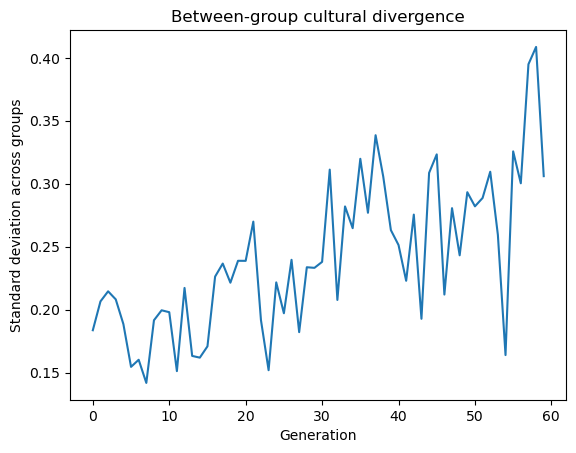

In [19]:
diversity = df.groupby("generation")["skill"].std()

plt.plot(diversity)
plt.title("Between-group cultural divergence")
plt.xlabel("Generation")
plt.ylabel("Standard deviation across groups")

## 10. Innovation dynamics

Reference:
Boyd & Richerson

Text(0, 0.5, 'Innovation probability')

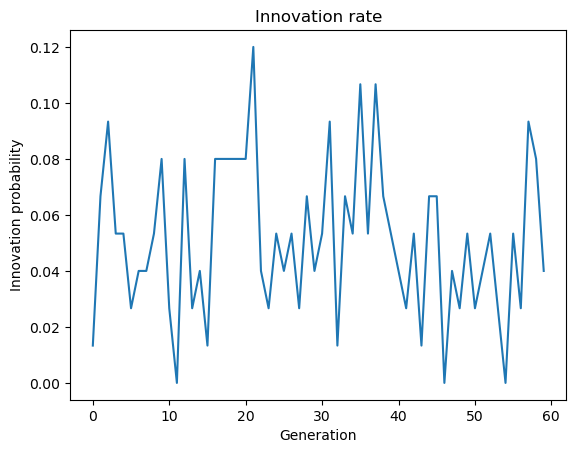

In [10]:
innovation = df.groupby("generation")["innovation"].mean()

innovation.plot()

plt.title("Innovation rate")
plt.xlabel("Generation")
plt.ylabel("Innovation probability")

Innovation declines
Selection dominates.

## 11. Cultural diversity

Text(0.5, 1.0, 'Cultural diversity')

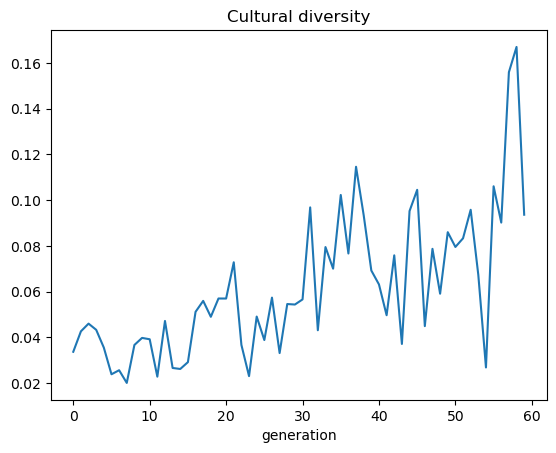

In [11]:
div = df.groupby("generation")["skill"].var()

div.plot()

plt.title("Cultural diversity")

Declining diversity = convergence.

## 12. Best trait accumulation

Text(0.5, 1.0, 'Best cultural trait accumulation')

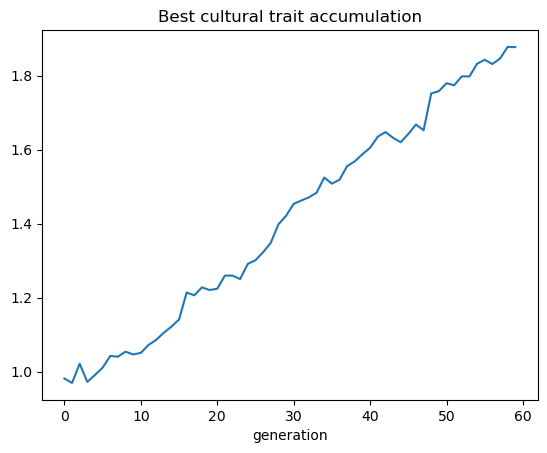

In [12]:
best = df.groupby("generation")["skill"].max()

best.plot()

plt.title("Best cultural trait accumulation")

This is cumulative culture.

## 13. Final summary figure

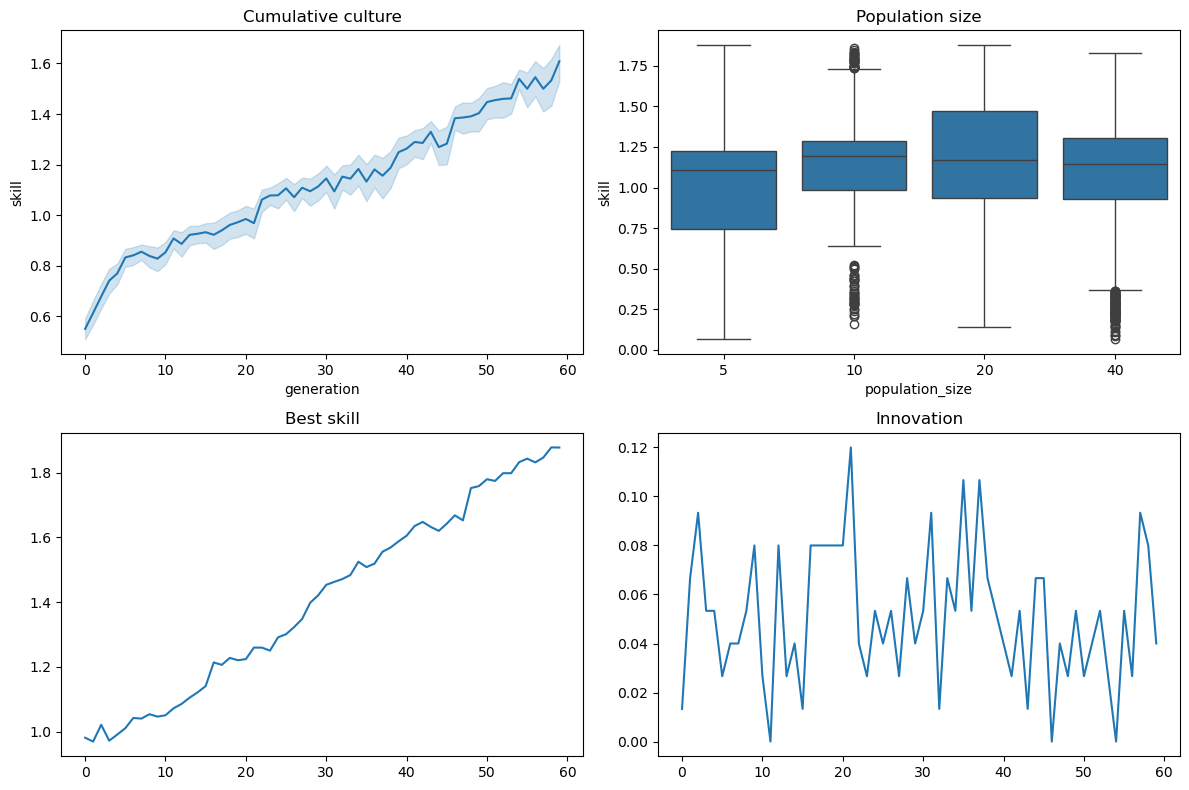

In [13]:
fig,axs = plt.subplots(2,2,figsize=(12,8))

sns.lineplot(data=df,x="generation",y="skill",ax=axs[0,0])
axs[0,0].set_title("Cumulative culture")

sns.boxplot(data=df,x="population_size",y="skill",ax=axs[0,1])
axs[0,1].set_title("Population size")

axs[1,0].plot(best)
axs[1,0].set_title("Best skill")

axs[1,1].plot(innovation)
axs[1,1].set_title("Innovation")

plt.tight_layout()